In [29]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


THEME = 'BrBG'



df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]

df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

# Calculate returns (price ratios Pt/Pt-1) as you did originally
df_og_returns = (df_original / df_original.shift(1) - 1).dropna() 
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean


# -------------------------------------------------
# 1. Your original parameters
# -------------------------------------------------
var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Factor loadings (7 observed x 7 latents)
Lambda_true = np.array([
    [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653,  0.360676, -0.608752], # gurkor
    [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640,  0.685579,  0.328278], # guitars
    [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878, -0.561128, -0.287903], # slingshots
    [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300, -0.015188,  0.000779], # stocks
    [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474, -0.108821, -0.038918], # sugar
    [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435, -0.257841,  0.661177], # water
    [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040, -0.080467,  0.009864]  # tranquillity
])

# VAR(2) coefficients (5 x 5)
# VAR(2) Lag 1 coefficients (7x7)
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557], # F0 eq
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590], # F1 eq
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809], # F2 eq
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002], # F3 eq
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988], # F4 eq
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336], # F5 eq
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]  # F6 eq
])

# VAR(2) Lag 2 coefficients (7x7)
Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700], # F0 eq
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445], # F1 eq
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037], # F2 eq
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329], # F3 eq
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718], # F4 eq
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123], # F5 eq
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]  # F6 eq
])

# Pruned VAR(2) Lag 1 coefficients (7x7)
# Removed: F0->F1, F1->F1, F2->F1, F4->F1, F2->F2, F4->F2, etc.
# Phi1 = np.array([
#     [ 0.066837,  0.000000,  0.000000, -0.129388, -0.120289, -0.162173,  0.000000], # F0 eq
#     [ 0.123793,  0.000000,  0.033206, -0.265276, -0.075745,  0.000000, -0.058590], # F1 eq
#     [ 0.026951,  0.000000,  0.000000, -0.045200,  0.000000,  0.000000,  0.000000], # F2 eq
#     [ 0.199106,  0.000000,  0.000000, -0.220926, -0.061257,  0.000000,  0.000000], # F3 eq
#     [-0.032751, -0.034423,  0.000000,  0.000000,  0.000000, -0.075896,  0.000000], # F4 eq
#     [ 0.016032,  0.000000,  0.000000, -0.033598, -0.052375, -0.296606,  0.000000], # F5 eq
#     [-0.014400,  0.000000,  0.021113, -0.040414,  0.000000,  0.035195, -0.182736]  # F6 eq
# ])

# # Pruned VAR(2) Lag 2 coefficients (7x7)
# Phi2 = np.array([
#     [ 0.000000,  0.000000,  0.000000, -0.076605,  0.000000, -0.084637,  0.000000], # F0 eq
#     [ 0.040158, -0.042788,  0.000000, -0.044778,  0.000000,  0.000000,  0.000000], # F1 eq
#     [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # F2 eq
#     [ 0.000000,  0.000000,  0.000000, -0.047150,  0.031045,  0.000000, -0.054329], # F3 eq
#     [ 0.000000,  0.028481,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # F4 eq
#     [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000, -0.070937,  0.000000], # F5 eq
#     [ 0.000000,  0.034619,  0.000000,  0.000000,  0.000000,  0.000000, -0.061284]  # F6 eq
# ])

garch_params = {
    0: {"omega": 0.0095, "alpha": 0.0051, "beta": 0.9858, "nu": 44.0171, "persistence": 0.9910},
    1: {"omega": 1.0849, "alpha": 0.0127, "beta": 0.0000, "nu": 79.4307, "persistence": 0.0127},
    2: {"omega": 0.0190, "alpha": 0.0000, "beta": 0.9812, "nu": 64.3650, "persistence": 0.9812},
    3: {"omega": 0.8047, "alpha": 0.0552, "beta": 0.1983, "nu": 125.7926, "persistence": 0.2536},
    4: {"omega": 0.8423, "alpha": 0.0043, "beta": 0.1709, "nu": 98.8637, "persistence": 0.1753},
    5: {"omega": 0.9961, "alpha": 0.0831, "beta": 0.0000, "nu": 123.0425, "persistence": 0.0831},
    6: {"omega": 1.0335, "alpha": 0.0224, "beta": 0.0000, "nu": 146.6895, "persistence": 0.0224},
}


from numpy.linalg import eigh

og_corr = df_og_returns.corr().values  # 7x7

# Eigendecomposition of the correlation matrix
eigenvalues, eigenvectors = eigh(og_corr)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Lambda that reproduces correlations: Λ @ Λ.T = Σ
# Each column scaled by sqrt(eigenvalue)
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

print("Implied correlation from corrected Lambda:")
print(np.round(Lambda_corrected @ Lambda_corrected.T, 3))


# -------------------------------------------------
# 2. Simulate the true factors from VAR(2)
# -------------------------------------------------
np.random.seed(69)
T = 4000
burn = 500

# Estimate degrees of freedom from original data
F_sim = np.zeros((T, 7))
h = np.ones((T, 7))


### Added stochastic voatility on a factor basis:
for t in range(2, T):
    for i in range(7):
        p = garch_params[i]
        h[t, i] = p['omega'] + p['alpha'] * F_sim[t-1, i]**2 + p['beta'] * h[t-1, i]
    
    # Independent t-innovations per factor (justified by near-zero residual correlations)
    innovations = np.array([
        np.random.standard_t(df=garch_params[i]['nu']) * 
        np.sqrt(h[t, i]) / np.sqrt(garch_params[i]['nu'] / (garch_params[i]['nu'] - 2))
        for i in range(7)
    ])
    
    F_sim[t] = Phi1 @ F_sim[t-1] + Phi2 @ F_sim[t-2] + innovations

F_sim = F_sim[burn:]
Y_sim = F_sim @ Lambda_corrected.T

# -------------------------------------------------
# 3. Generate observed data (no idiosyncratic noise for verification)
#    Y = F @ Lambda_true.T
# -------------------------------------------------


# Z-score to match your original preprocessing
# df_sim = pd.DataFrame(StandardScaler().fit_transform(df_sim), columns=var_names)

# -------------------------------------------------
# 4. Re-extract factors via PCA (as you presumably did originally)
# -------------------------------------------------
pca = PCA(n_components=7)
F_est = pca.fit_transform(Y_sim)          # (T x 5) scores
Lambda_est = pca.components_.T             # (7 x 5) loadings

# -------------------------------------------------
# 5. PROCRUSTES ALIGNMENT (the missing step)
# -------------------------------------------------
# Find rotation matrix R that minimizes ||F - F_est @ R||_F
R, _ = orthogonal_procrustes(F_est, F_sim)     # Note: (estimated, target)

# Apply rotation to factors and loadings
F_aligned = F_est @ R
Lambda_aligned = Lambda_est @ R

# Fix sign ambiguity (flip signs to match original where possible)
signs = np.sign(np.diag(Lambda_aligned.T @ Lambda_corrected))
Lambda_aligned = Lambda_aligned * signs
F_aligned = F_aligned * signs

# -------------------------------------------------
# 6. Compare
# -------------------------------------------------
print("Original Loadings:")
print(pd.DataFrame(Lambda_corrected, index=var_names, columns=[f"F{i}" for i in range(7)]))
print("\nAligned Simulated Loadings:")
print(pd.DataFrame(np.round(Lambda_aligned, 6), index=var_names, columns=[f"F{i}" for i in range(7)]))

# Check correlation between true and aligned factors (should be ~1)
print("\nCorrelation between true and aligned factors:")
print(np.diag(np.corrcoef(F_sim.T, F_aligned.T)[:7, 7:]).round(4))

Implied correlation from corrected Lambda:
[[ 1.    -0.326 -0.291 -0.045 -0.081  0.623 -0.148]
 [-0.326  1.     0.553  0.028  0.216 -0.369  0.269]
 [-0.291  0.553  1.     0.018  0.127 -0.259  0.21 ]
 [-0.045  0.028  0.018  1.    -0.021 -0.05   0.002]
 [-0.081  0.216  0.127 -0.021  1.    -0.091  0.142]
 [ 0.623 -0.369 -0.259 -0.05  -0.091  1.    -0.18 ]
 [-0.148  0.269  0.21   0.002  0.142 -0.18   1.   ]]
Original Loadings:
                    F0        F1        F2        F3        F4        F5  \
gurkor       -0.713171  0.454613  0.225253 -0.203421 -0.039046 -0.240568   
guitars       0.765309  0.223492  0.095863 -0.242347 -0.216908 -0.459444   
slingshots    0.682956  0.215826  0.096077 -0.452786 -0.318953  0.376324   
stocks        0.069536 -0.400830  0.910010  0.079113 -0.004852  0.009898   
sugar         0.313867  0.566307  0.138483  0.713587 -0.215796  0.072806   
water        -0.727842  0.429125  0.205859 -0.220627 -0.091871  0.171401   
tranquillity  0.451525  0.372601  0.14340

Original returns standard deviations:
gurkor          0.004068
guitars         0.016023
slingshots      0.016352
stocks          0.014869
sugar           0.015781
water           0.003534
tranquillity    0.013334
dtype: float64

Simulated standardized returns (should be ~N(0,1)):
gurkor          1.080115
guitars         1.077779
slingshots      1.058519
stocks          1.015596
sugar           1.126958
water           1.039384
tranquillity    1.031989
dtype: float64

Simulated returns volatilities (should match original):
gurkor          0.004068
guitars         0.016023
slingshots      0.016352
stocks          0.014869
sugar           0.015781
water           0.003534
tranquillity    0.013334
dtype: float64


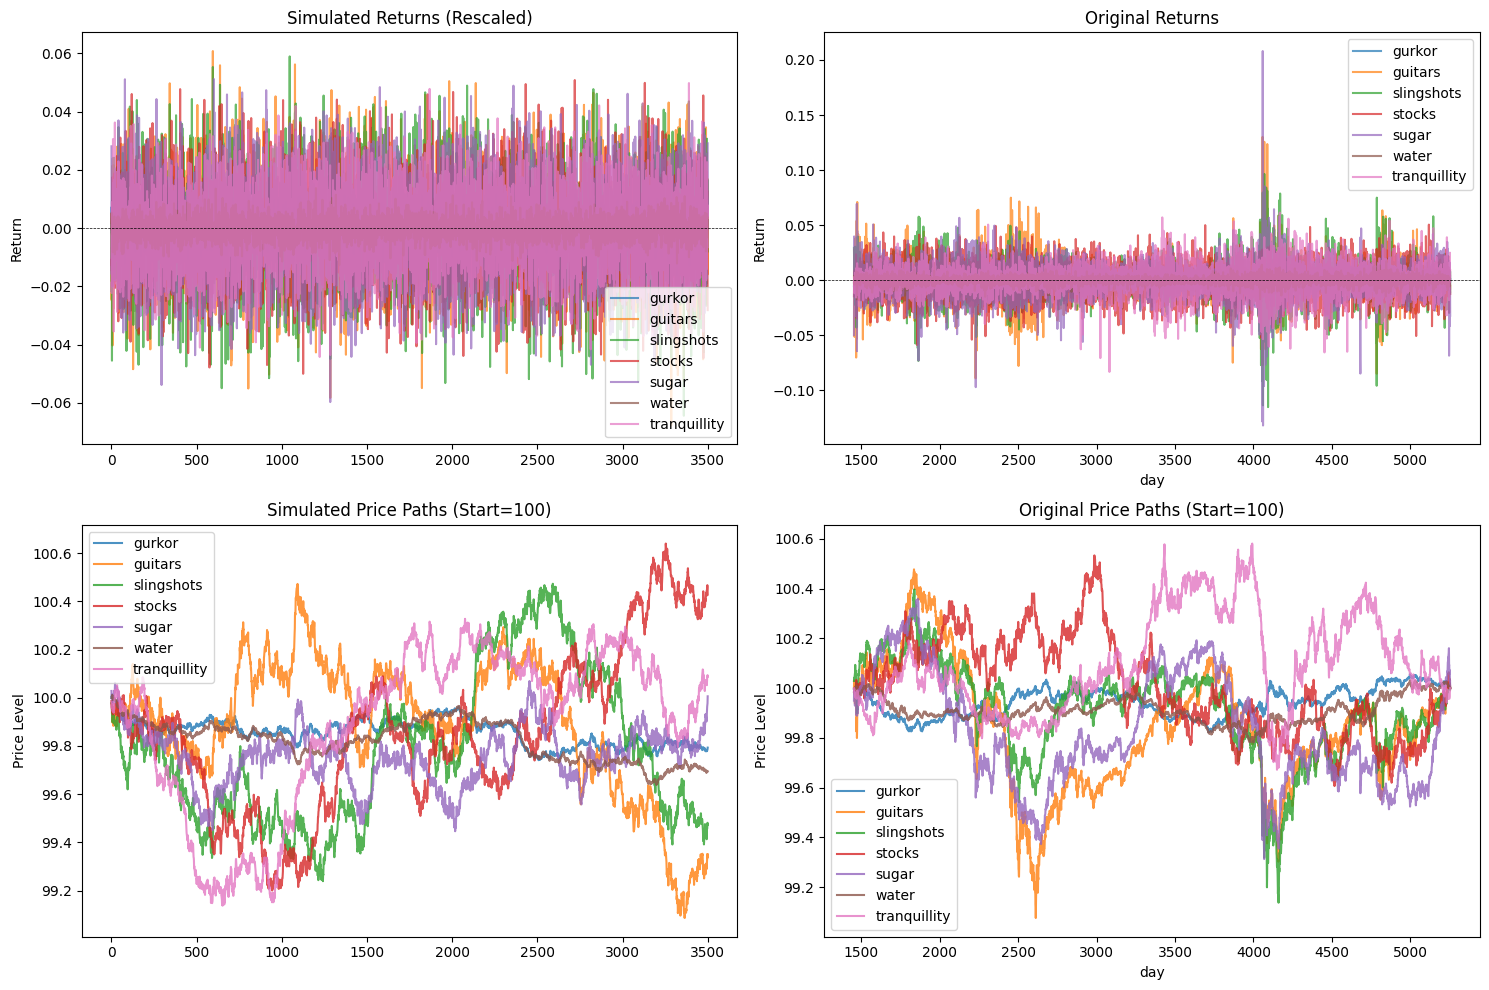


Volatility comparison (Original vs Simulated):
              Original  Simulated  Ratio
gurkor          0.0041     0.0041    1.0
guitars         0.0160     0.0160    1.0
slingshots      0.0164     0.0164    1.0
stocks          0.0149     0.0149    1.0
sugar           0.0158     0.0158    1.0
water           0.0035     0.0035    1.0
tranquillity    0.0133     0.0133    1.0


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# -------------------------------------------------
# 1. Load original data and get scaling parameters
# -------------------------------------------------

# Get standard deviations (for rescaling the simulation back)
original_stds = df_og_returns.std()
print("Original returns standard deviations:")
print(original_stds)

# -------------------------------------------------
# 2. Define your factor model parameters
# # -------------------------------------------------
# Lambda_true = np.array([
#     [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653],
#     [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640],
#     [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878],
#     [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300],
#     [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474],
#     [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435],
#     [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040]
# ])

# Phi1 = np.array([
#     [ 0.069570, -0.045041, -0.032271, -0.126121, -0.116237],
#     [ 0.123517, -0.006882,  0.033199, -0.266336, -0.075593],
#     [ 0.027233,  0.014420, -0.000103, -0.045385, -0.024730],
#     [ 0.198330,  0.008947,  0.016066, -0.222132, -0.061226],
#     [-0.032710, -0.032482,  0.001286,  0.015577, -0.016760]
# ])

# Phi2 = np.array([
#     [ 0.013774, -0.033803,  0.025312, -0.071823,  0.012382],
#     [ 0.042048, -0.043486,  0.014998, -0.043731,  0.009972],
#     [ 0.011989, -0.002305, -0.016781, -0.016861, -0.030828],
#     [ 0.018717, -0.000719, -0.003339, -0.048658,  0.031319],
#     [ 0.003668,  0.029666,  0.001740,  0.012825, -0.005191]
# ])

# # -------------------------------------------------
# # 3. Simulate VAR(2) factors (same as your original)
# # -------------------------------------------------
# np.random.seed(42)
# T = 4000
# burn = 500
# F = np.zeros((T, 5))

# for t in range(2, T):
#     F[t] = Phi1 @ F[t-1] + Phi2 @ F[t-2] + np.random.randn(5)

# F = F[burn:]  # Stationary sample

# -------------------------------------------------
# 4. Reconstruct standardized returns from factors
# -------------------------------------------------
# This gives you z-scored returns (mean 0, std 1) because factors are N(0,1) and loadings are orthogonal
Y_std = Y_sim
df_recon_std = pd.DataFrame(Y_std, columns=var_names)
print("\nSimulated standardized returns (should be ~N(0,1)):")
print(df_recon_std.std())
# -------------------------------------------------
# 5. STANDARDIZE simulated returns first, then rescale to original volatility
# -------------------------------------------------
# Y_std currently has variance = sum of squared loadings per row (not 1)
Y_current_stds = pd.DataFrame(Y_sim, columns=var_names).std()

df_returns_sim = pd.DataFrame(Y_sim, columns=var_names).multiply(
    original_stds / Y_current_stds, axis=1
)


print("\nSimulated returns volatilities (should match original):")
print(df_returns_sim.std())

# -------------------------------------------------
# 6. Accumulate to price series (start at 100)
# -------------------------------------------------
start_value = 100
df_prices_sim = start_value + df_returns_sim.cumsum()
df_prices_original = start_value + df_og_returns.cumsum()

# -------------------------------------------------
# 7. Plot comparison
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Simulated returns (rescaled to original volatility)
df_returns_sim.plot(ax=axes[0,0], alpha=0.7, title='Simulated Returns (Rescaled)')
axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,0].set_ylabel('Return')

# Plot 2: Original returns
df_og_returns.plot(ax=axes[0,1], alpha=0.7, title='Original Returns')
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,1].set_ylabel('Return')

# Plot 3: Simulated prices (cumsum)
df_prices_sim.plot(ax=axes[1,0], alpha=0.8, title='Simulated Price Paths (Start=100)')
axes[1,0].set_ylabel('Price Level')

# Plot 4: Original prices (cumsum)
df_prices_original.plot(ax=axes[1,1], alpha=0.8, title='Original Price Paths (Start=100)')
axes[1,1].set_ylabel('Price Level')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 8. Validation: Volatility comparison
# -------------------------------------------------
print("\nVolatility comparison (Original vs Simulated):")
comparison = pd.DataFrame({
    'Original': original_stds,
    'Simulated': df_returns_sim.std(),
    'Ratio': df_returns_sim.std() / original_stds
})
print(comparison.round(4))

Obviously we are missing the variance clustering.

In [21]:
# What your model implies for the correlation of observed variables
F_cov = np.cov(F_sim.T)  # 7x7 factor covariance
Y_cov_implied = Lambda_true @ F_cov @ Lambda_true.T
Y_corr_implied = np.corrcoef(Y_sim.T)

print("Implied correlation between gurkor and guitars:")
print(Y_corr_implied[0, 1])  # should match original data

Implied correlation between gurkor and guitars:
-0.3283790898031616


In [22]:
og_corr = df_og_returns.corr()
sim_corr = pd.DataFrame(Y_corr_implied, index=var_names, columns=var_names)

# Side by side
print("Original:\n", og_corr.round(3))
print("\nSimulated:\n", sim_corr.round(3))

Original:
               gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148
guitars       -0.326    1.000       0.553   0.028  0.216 -0.369         0.269
slingshots    -0.291    0.553       1.000   0.018  0.127 -0.259         0.210
stocks        -0.045    0.028       0.018   1.000 -0.021 -0.050         0.002
sugar         -0.081    0.216       0.127  -0.021  1.000 -0.091         0.142
water          0.623   -0.369      -0.259  -0.050 -0.091  1.000        -0.180
tranquillity  -0.148    0.269       0.210   0.002  0.142 -0.180         1.000

Simulated:
               gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.328      -0.328  -0.042 -0.121  0.630        -0.191
guitars       -0.328    1.000       0.540  -0.014  0.239 -0.387         0.284
slingshots    -0.328    0.540       1.000  -0.013  0.157 -0.272         0.276
stocks        -0.042   -0.014      -0.01

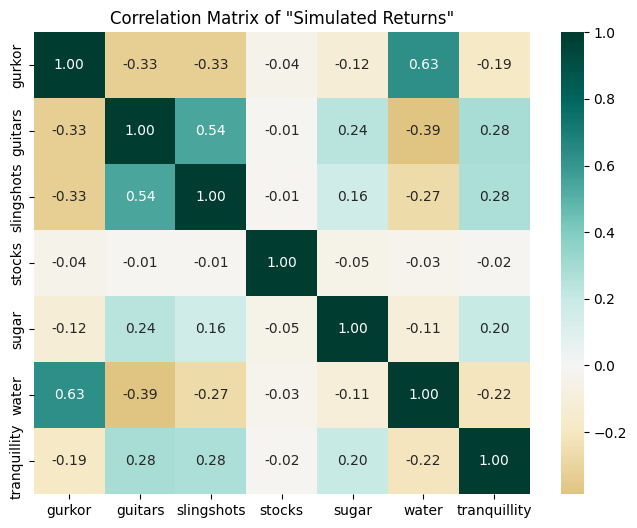

=============================== SIMULATED RETURNS PCA ================================


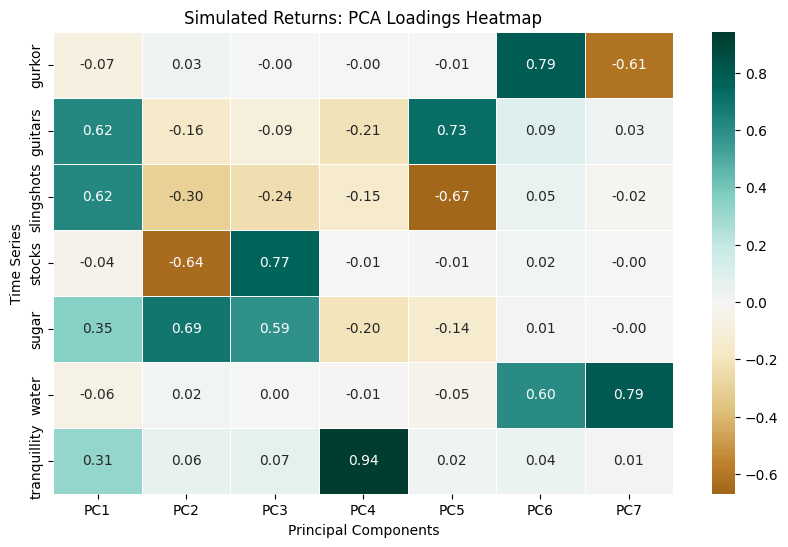

Explained Variance Ratio per Component:
PC1: 0.3895 (38.95%)
PC2: 0.1930 (19.30%)
PC3: 0.1775 (17.75%)
PC4: 0.1211 (12.11%)
PC5: 0.0987 (9.87%)
PC6: 0.0160 (1.60%)
PC7: 0.0042 (0.42%)

Cumulative Variance Explained by top 3 components: 76.00%


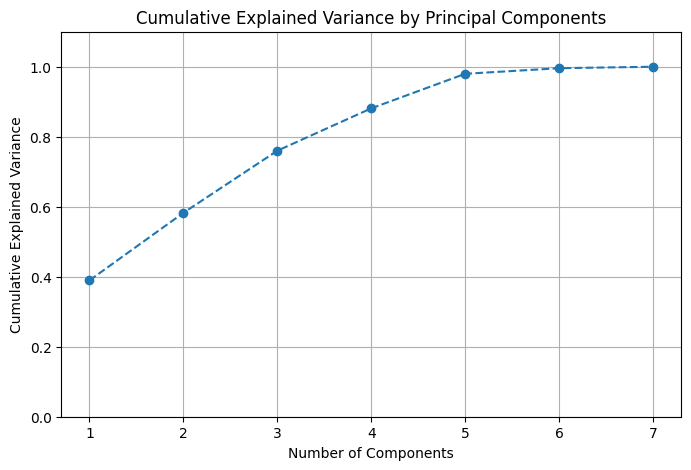

=== PRINCIPAL COMPONENT DRIVERS ===

PC1 is primarily driven by:
  guitars         | Weight:  0.6200 | 🟢 Positive
  slingshots      | Weight:  0.6172 | 🟢 Positive
  sugar           | Weight:  0.3533 | 🟢 Positive
  tranquillity    | Weight:  0.3146 | 🟢 Positive

PC2 is primarily driven by:
  sugar           | Weight:  0.6859 | 🟢 Positive
  stocks          | Weight: -0.6407 | 🔴 Negative
  slingshots      | Weight: -0.2995 | 🔴 Negative

PC3 is primarily driven by:
  stocks          | Weight:  0.7665 | 🟢 Positive
  sugar           | Weight:  0.5858 | 🟢 Positive


--- Simulated Returns Variance Explained ---
Top 3 components explain: 76.00%

PCA Loadings (How much each series contributes to each PC):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
gurkor       -0.073622  0.026527 -0.000691 -0.003212 -0.005168  0.789670   
guitars       0.620003 -0.156054 -0.091483 -0.211934  0.727708  0.087607   
slingshots    0.617209 -0.299522 -0.235641 -0.152602 -0.669234  0.0

In [23]:

import seaborn as sns

# Calculate Returns and align metadata

# --- 2. CORRELATION ANALYSIS ---
plt.figure(figsize=(8, 6))
sns.heatmap(df_returns_sim.corr(), annot=True, cmap=THEME, center=0, fmt=".2f")
plt.title('Correlation Matrix of "Simulated Returns"')
plt.show()

# --- 3. PCA FUNCTION ---
# Building a function keeps your code DRY (Don't Repeat Yourself) 
# and prevents variable overwriting.
def run_and_plot_pca(data, title_prefix):
    # Standardize
    #scaler = StandardScaler()
    #scaled_data = scaler.fit_transform(data)
    scaled_data = data
    # Fit PCA
    pca = PCA()
    pca.fit(scaled_data)
    
    # Loadings extraction
    loadings_df = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
        index=data.columns
    )
    
    # Plot Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(loadings_df, annot=True, cmap=THEME, center=0, fmt=".2f", linewidths=0.5)
    plt.title(f'{title_prefix}: PCA Loadings Heatmap')
    plt.xlabel('Principal Components')
    plt.ylabel('Time Series')
    plt.show()

    # explained var
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    print("Explained Variance Ratio per Component:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

    print(f"\nCumulative Variance Explained by top 3 components: {cumulative_variance[2]*100:.2f}%")

    # Plot the Scree Plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 8), cumulative_variance, marker='o', linestyle='--')
    plt.title('Cumulative Explained Variance by Principal Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.ylim(0, 1.1)
    plt.show()

    print("=== PRINCIPAL COMPONENT DRIVERS ===")
    for pc in ['PC1', 'PC2', 'PC3']:
        print(f"\n{pc} is primarily driven by:")
        
        # Sort the features by their absolute contribution to this PC
        sorted_features = loadings_df[pc].abs().sort_values(ascending=False)
        
        for feature, abs_weight in sorted_features.items():
            actual_weight = loadings_df.loc[feature, pc]
            
            # Threshold: We only print features that have a meaningful impact (e.g., > 0.3)
            # Loadings are constrained between -1 and 1.
            if abs_weight > 0.25:
                direction = "🟢 Positive" if actual_weight > 0 else "🔴 Negative"
                print(f"  {feature:<15} | Weight: {actual_weight:>7.4f} | {direction}")

    print("\n" + "="*35 + "\n")
    
    # Variance Explained
    cumulative_var = np.cumsum(pca.explained_variance_ratio_)
    print(f"--- {title_prefix} Variance Explained ---")
    print(f"Top 3 components explain: {cumulative_var[2]*100:.2f}%\n")

    loadings = pd.DataFrame(
    pca.components_.T,  # Transpose the matrix
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=data.columns # Your original 7 column names
)

    print("PCA Loadings (How much each series contributes to each PC):")
    print(loadings)
    
    return pca, loadings_df

# --- 4. EXECUTE COMPARISON ---

print(80*"=")
print(f'{31* '='} SIMULATED RETURNS PCA {32* '='}')
print(80*"=")
pca_returns, loadings_returns = run_and_plot_pca(df_returns_sim, "Simulated Returns")

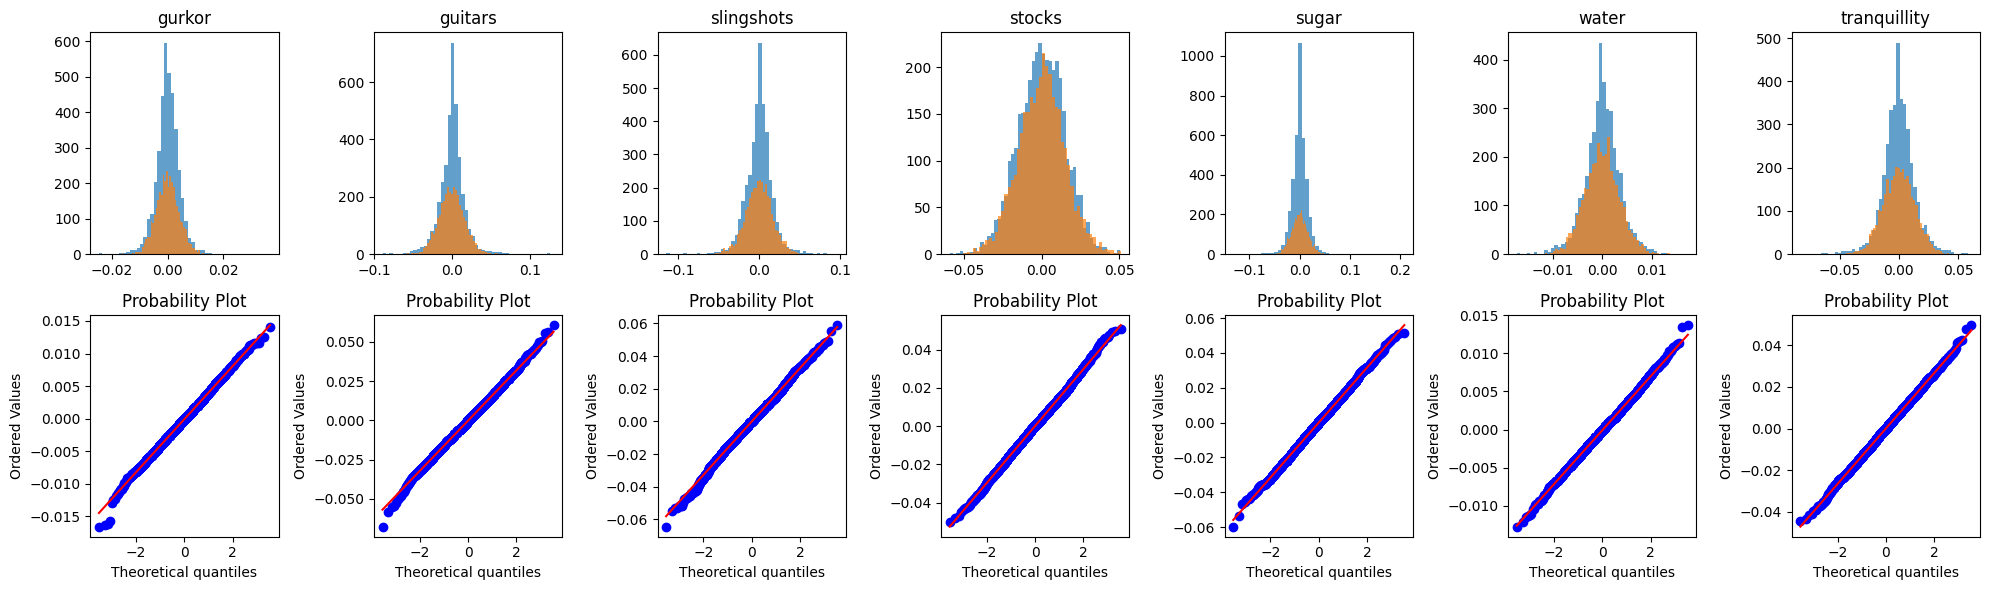

gurkor: skew -0.06 vs 0.00 | kurt 3.62 vs 0.12
guitars: skew 0.21 vs 0.01 | kurt 5.75 vs 0.23
slingshots: skew -0.21 vs -0.08 | kurt 4.70 vs 0.24
stocks: skew -0.09 vs 0.01 | kurt 0.05 vs 0.14
sugar: skew 0.03 vs -0.00 | kurt 13.47 vs -0.05
water: skew -0.14 vs 0.04 | kurt 1.64 vs 0.15
tranquillity: skew -0.20 vs 0.00 | kurt 2.59 vs -0.03


In [27]:
from scipy import stats

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
for i, col in enumerate(var_names):
    axes[0, i].hist(df_og_returns[col], bins=50, alpha=0.7, label='Original')
    axes[0, i].hist(df_returns_sim[col], bins=50, alpha=0.7, label='Simulated')
    axes[0, i].set_title(col)
    
    # QQ plot
    stats.probplot(df_returns_sim[col], plot=axes[1, i])
plt.tight_layout()
plt.show()

# Moments comparison
for col in var_names:
    print(f"{col}: skew {df_og_returns[col].skew():.2f} vs {df_returns_sim[col].skew():.2f} | "
          f"kurt {df_og_returns[col].kurt():.2f} vs {df_returns_sim[col].kurt():.2f}")

Detta gav oss att vi inte skulle ha Gaussian shocks! Måste ju fånga tailen!

Empirical nu estimates from observed returns:
  gurkor: nu ≈ 5.20
  guitars: nu ≈ 3.02
  slingshots: nu ≈ 3.83
  stocks: nu ≈ 149.70
  sugar: nu ≈ 3.66
  water: nu ≈ 5.48
  tranquillity: nu ≈ 4.47


In [25]:
# If squared returns are autocorrelated, there's volatility clustering
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in var_names:
    lb = acorr_ljungbox(df_og_returns[col]**2, lags=10, return_df=True)
    print(f"{col}: Ljung-Box p-value (squared returns) = {lb['lb_pvalue'].min():.4f}")
# p < 0.05 means significant volatility clustering

gurkor: Ljung-Box p-value (squared returns) = 0.0000
guitars: Ljung-Box p-value (squared returns) = 0.0000
slingshots: Ljung-Box p-value (squared returns) = 0.0000
stocks: Ljung-Box p-value (squared returns) = 0.2506
sugar: Ljung-Box p-value (squared returns) = 0.0000
water: Ljung-Box p-value (squared returns) = 0.0000
tranquillity: Ljung-Box p-value (squared returns) = 0.0000


In [26]:
Nästa steg: fixa kurtosis och vol clustering!

SyntaxError: invalid syntax (2776075913.py, line 1)